This notebook should serve as an extensible benchmark for methods predicting spatial cell counts from single cell data

## Setup

### Load Modules

In [2]:
import os
import sys
from pathlib import Path
from typing import Callable, NamedTuple, List
from dataclasses import dataclass
from functools import partial

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
import sklearn as sk
import torch
from tqdm import tqdm
import tangram as tg
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import non_negative_factorization
from sklearn.metrics import mean_squared_error

### Data Utils

In [172]:
from ast import Call


class Reconstruction_Result(NamedTuple):
    """
    A class to store the original and predicted gene counts along with methods
    to process and compute metrics based on those counts.

    Attributes:
        original_counts (pd.DataFrame): The original gene counts from the query data.
        predicted_counts (pd.DataFrame): The predicted gene counts from the gene prediction model.
    """

    original_counts: pd.DataFrame
    predicted_counts: pd.DataFrame

    @classmethod
    def from_gene_predictor(
        cls,
        adata_query: ad.AnnData,
        compidx: np.ndarray[str],
        subidx: np.ndarray[str],
        gene_predictor: Callable[[ad.AnnData, np.ndarray[str], np.ndarray[str]], np.ndarray],
    ) -> "Reconstruction_Result":
        """
        Creates a Reconstruction_Result instance from a gene prediction model.

        Args:
            adata_query (ad.AnnData): The AnnData object containing the query data (e.g., query spatial data).
            compidx (np.ndarray[str]): A list of gene identifiers to be predicted.
            gene_predictor (Callable[[ad.AnnData, np.ndarray[str]], np.ndarray]): A function that predicts gene counts
                based on the query AnnData object and the list of gene identifiers. It should return a NumPy array
                of predicted counts.

        Returns:
            Reconstruction_Result: A new instance containing the original and predicted gene counts as DataFrames.
        """
        return Reconstruction_Result( 
            pd.DataFrame(
                data=adata_query[:, compidx].X,
                columns=compidx
            ),
            pd.DataFrame(
                data=gene_predictor(adata_query, compidx, subidx),
                columns=compidx
            )
        )

    def compute_correlation(
        self,
        correlation_func: Callable[[np.ndarray, np.ndarray], float],
    ) -> float:
        """
        Computes the correlation between the original and predicted gene counts.

        Args:
            correlation_func (Callable[[np.ndarray, np.ndarray], float]): A function that computes the correlation
                between two NumPy arrays. It should return a single floating-point value representing the correlation.

        Returns:
            float: The computed correlation between the original and predicted gene counts.
        """
        return correlation_func(
            self.original_counts.values,
            self.predicted_counts.values
        )
    
    def combine(
        self,
        reconstruction_result: "Reconstruction_Result",
        combine_func: Callable[[np.ndarray, np.ndarray], np.ndarray]
    ):
        return self

def transform_correlation_func(
    correlation_func: Callable[[np.ndarray, np.ndarray], float], 
    transform: Callable[[np.ndarray], np.ndarray]
) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Returns a correlation function that applies a transformation to inputs before computing correlation.
    """
    return lambda x, y: correlation_func(transform(x), transform(y))


### NMF Utils

In [4]:
def prepare_H_init(
    adata_reference: ad.AnnData,
    shared_genes: np.ndarray,
    n_components: int
) -> pd.DataFrame:

    _, H_init, _ = non_negative_factorization(
        adata_reference[:, shared_genes].X.toarray(), 
        n_components=n_components
    )

    return pd.DataFrame(
        data=H_init,
        columns=shared_genes
    )

def predict_genes_nmf(
    adata_query: sc.AnnData, 
    H_init: pd.DataFrame,
    compidx: np.ndarray[str],
    subidx: np.ndarray[str],
) -> np.ndarray:


    W, _, _ = non_negative_factorization(
        adata_query[:, subidx].X, 
        H=H_init[subidx].values,
        init="custom", 
        update_H=False,
        n_components=H_init.shape[0],
    )
    return W @ H_init[compidx].values

### Autoencoder Utils

#### Architecture

In [5]:
def ReLU(Z):
    return np.maximum(0, Z)

def ReLU_backward(dZ, Z):
    dZ[Z <= 0] = 0
    return dZ

@dataclass
class LinearLayer:
    W: np.ndarray
    b: np.ndarray

    def __post_init__(self):
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.input_cache = None  

    def forward(self, Z):
        self.input_cache = Z 
        return (Z @ self.W) + self.b
    
    def backward(self, dZ):
        dW = self.input_cache.T @ dZ  
        db = np.sum(dZ, axis=0, keepdims=True)  

        dZ_prev = dZ @ self.W.T 

        self.dW = dW
        self.db = db

        return dZ_prev 
    
    def __call__(self, Z):
        return self.forward(Z)

class Model:
    def __init__(self, n_input, n_latent, n_output):
        self.fc1 = LinearLayer(
            W=np.random.randn(n_input, n_latent) * np.sqrt(2 / (n_input + n_latent)),
            b=np.zeros((1, n_latent))
        )
        self.fc2 = LinearLayer(
            W=np.random.randn(n_latent, n_output) * np.sqrt(2 / (n_latent + n_output)),
            b=np.zeros((1, n_output))
        )

    def forward(self, Z):
        self.Z1 = self.fc1(Z)  
        self.A1 = ReLU(self.Z1)
        self.Z2 = self.fc2(self.A1) 
        return self.Z2

    def backward(self, dZ2):
        """Backpropagate gradients through the network."""
        dA1 = self.fc2.backward(dZ2)
        dZ1 = ReLU_backward(dA1, self.Z1)
        dX = self.fc1.backward(dZ1)
        return dX 

    def update_parameters(self, lr=0.01):
        """Update parameters using gradient descent."""
        self.fc1.W -= lr * self.fc1.dW
        self.fc1.b -= lr * self.fc1.db
        self.fc2.W -= lr * self.fc2.dW
        self.fc2.b -= lr * self.fc2.db

    def __call__(self, Z):
        return self.forward(Z)

    def train(
        self,
        data,
        n_epochs,
        learning_rate
    ):
        for _ in tqdm(range(n_epochs)):
            pass


#### Predictor

### Tangram Utils

In [62]:
def predict_genes_tangram(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    compidx: np.ndarray[str], 
    subidx: np.ndarray[str],
    *args,
    **kwargs
) -> np.ndarray:

    markers = np.hstack([compidx, subidx])

    adata_reference = adata_reference[:, markers]
    adata_query_subidx = adata_query[:, subidx]

    tg.pp_adatas(adata_reference, adata_query_subidx, genes=markers.tolist())

    ad_map = tg.map_cells_to_space(
        adata_sc=adata_reference,
        adata_sp=adata_query_subidx,
        *args,
        **kwargs
    )
    ad_ge = tg.project_genes(ad_map, adata_reference)

    return ad_ge[:, list(map(lambda str: str.lower(), compidx))].X

### Load Data

In [7]:
# Query Dataset
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reference Dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.array(list(set.intersection(set(adata_sp.var_names), set(adata_sc.var_names))))

adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [8]:
adata_sp = adata_sp[adata_sp.obs["celltype"] == "Stem/TA"]
adata_sc = adata_sc[adata_sc.obs["celltype"] == "Stem/TA"]

## Main

In [99]:
def benchmark_gene_predictor(
    adata_query: ad.AnnData,
    adata_reference: ad.AnnData,
    n_runs: int, 
    n_compidx: int,
    gene_predictor: Callable[[ad.AnnData, np.ndarray[str], np.ndarray[str]], Reconstruction_Result]
) -> List[Reconstruction_Result]:
    """
    Benchmarks a gene prediction model by evaluating its performance across multiple randomized gene sets.

    This function identifies shared genes between the query and reference datasets, 
    generates multiple random permutations of these genes, and evaluates the given gene predictor 
    using subsets of genes as input and output.

    Args:
        adata_query (ad.AnnData): The query AnnData object containing the spatial gene expression data.
        adata_reference (ad.AnnData): The reference AnnData object containing the single-cell gene expression data.
        n_runs (int): The number of random permutations to generate for benchmarking.
        n_compidx (int): The number of genes to use as input (compidx) in each benchmark run.
        gene_predictor (Callable[[ad.AnnData, np.ndarray[str], np.ndarray[str]], Reconstruction_Result]): 
            A function that predicts gene expression given a query dataset and two gene subsets.

    Returns:
        List[Reconstruction_Result]: A list of Reconstruction_Result objects, each containing 
        the original and predicted gene expression values for a given permutation.
    """
    
    shared_genes = np.array(list(
        set.intersection(
            set(adata_query.var_names[sc.pp.filter_genes(adata_sp, min_cells=1, inplace=False)[0]]),
            set(adata_reference.var_names[sc.pp.filter_genes(adata_sc, min_cells=1, inplace=False)[0]]),
        )
    ))
    benchmarking_genes = [np.random.default_rng(seed=seed).permutation(shared_genes) for seed in range(n_runs)]

    return [
        Reconstruction_Result.from_gene_predictor(adata_query, gene_arr[:n_compidx], gene_arr[n_compidx:], gene_predictor)
        for gene_arr in benchmarking_genes
    ]

In [128]:
nmf_result = benchmark_gene_predictor(adata_sp, adata_sc, 50, 40, nmf_predictor)

In [83]:
H_init = prepare_H_init(adata_sc, shared_genes, 3)
# For all methods, the "predictor" has to be a function that takes the query dataset, the genes to be predicted and the genes used for prediction and return the predicted counts as a numpy array
nmf_predictor = lambda adata_query, compidx, subidx: predict_genes_nmf(
    adata_query,
    H_init,
    compidx,
    subidx
)

nmf_result = benchmark_gene_predictor(adata_sp, adata_sc, 50, 40, nmf_predictor)

In [64]:
tangram_predictor = lambda adata_query, compidx, subidx: predict_genes_tangram(
    adata_query,
    adata_sc,
    compidx,
    subidx,
    device="mps"
)
tangram_result = benchmark_gene_predictor(adata_sp, adata_sc, 50, 40, tangram_predictor)

INFO:root:98 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.


INFO:root:98 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 98 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.251, KL reg: 0.326
Score: 0.872, KL reg: 0.005
Score: 0.877, KL reg: 0.005
Score: 0.878, KL reg: 0.005
Score: 0.879, KL reg: 0.005
Score: 0.879, KL reg: 0.005
Score: 0.879, KL reg: 0.004
Score: 0.879, KL reg: 0.004
Score: 0.880, KL reg: 0.004
Score: 0.880, KL reg: 0.004


INFO:root:Saving results..
INFO:root:98 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:98 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 98 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.227, KL reg: 0.325
Score: 0.883, KL reg: 0.004
Score: 0.887, KL reg: 0.003
Score: 0.889, KL reg: 0.003
Score: 0.889, KL reg: 0.003
Score: 0.889, KL reg: 0.003
Score: 0.890, KL reg: 0.003
Score: 0.890, KL reg: 0.003
Score: 0.890, KL reg: 0.003
Score: 0.890, KL reg: 0.003


...

INFO:root:Saving results..
INFO:root:98 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:98 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 98 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.229, KL reg: 0.339
Score: 0.875, KL reg: 0.005
Score: 0.880, KL reg: 0.005
Score: 0.881, KL reg: 0.005
Score: 0.882, KL reg: 0.005
Score: 0.882, KL reg: 0.005
Score: 0.882, KL reg: 0.005
Score: 0.882, KL reg: 0.004
Score: 0.882, KL reg: 0.004
Score: 0.882, KL reg: 0.004


INFO:root:Saving results..
INFO:root:98 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:98 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 98 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.235, KL reg: 0.336
Score: 0.882, KL reg: 0.005
Score: 0.887, KL reg: 0.004
Score: 0.888, KL reg: 0.004
Score: 0.889, KL reg: 0.004
Score: 0.889, KL reg: 0.004
Score: 0.889, KL reg: 0.004
Score: 0.889, KL reg: 0.004
Score: 0.889, KL reg: 0.004
Score: 0.889, KL reg: 0.004


INFO:root:Saving results..


In [134]:

test1 = benchmark_gene_predictor(adata_sp, adata_sc, 50, 40, nmf_predictor)
test2 = test1.copy()

In [169]:
pearsonr_mean = transform_correlation_func(
    lambda x, y: float(pearsonr(x, y)[0]), 
    lambda x: x.mean(axis=0)
)

pearsonr_log_mean = transform_correlation_func(
    lambda x, y: float(pearsonr(x, y)[0]), 
    lambda x: np.log(x.mean(axis=0) + 1e-3)
)

spearmanr_mean = transform_correlation_func(
    lambda x, y: float(spearmanr(x, y)[0]), 
    lambda x: x.mean(axis=0)
)

In [ ]:
np.mean()

In [171]:
def concat_reconstruction_result(
    reconstruction_results: list[Reconstruction_Result]
) -> Reconstruction_Result:
    pass

In [163]:
results = test1, test2

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


(0.0, 1.0)

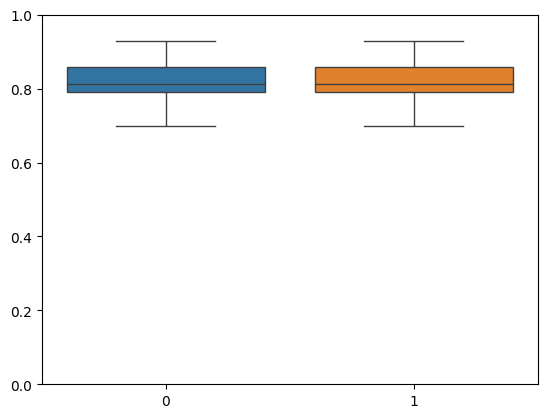

In [170]:
sns.boxplot(data = [[reconstruction_result.compute_correlation(pearsonr_log_mean) for reconstruction_result in result] for result in results])
plt.ylim(0, 1)

ValueError: X must have 2 or fewer dimensions

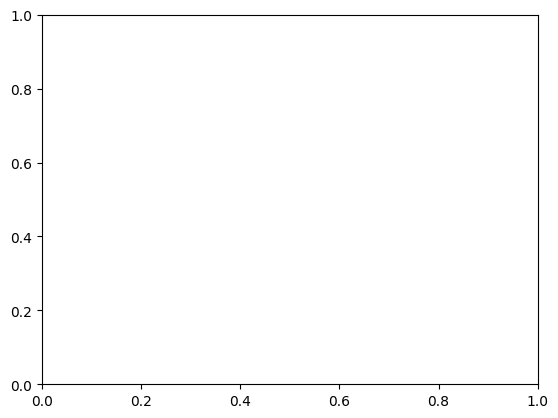

In [132]:
plt.boxplot(test1)

(0.0, 1.0)

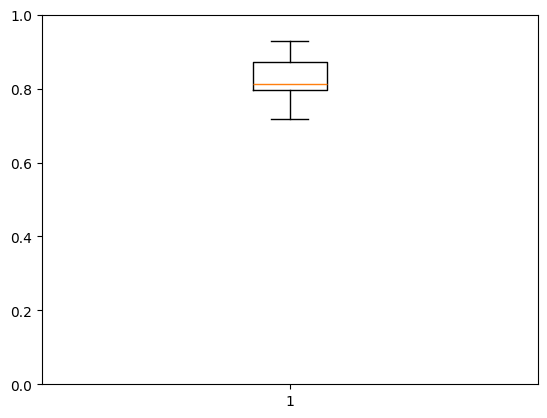

In [85]:
plt.boxplot(
    [res.compute_correlation(lambda arr_1, arr_2: float(pearsonr(np.log(arr_1.mean(axis=0) + 1e-3), np.log(arr_2.mean(axis=0) + 1e-3))[0])) for res in nmf_res]
)
plt.ylim(0, 1)

(0.0, 1.0)

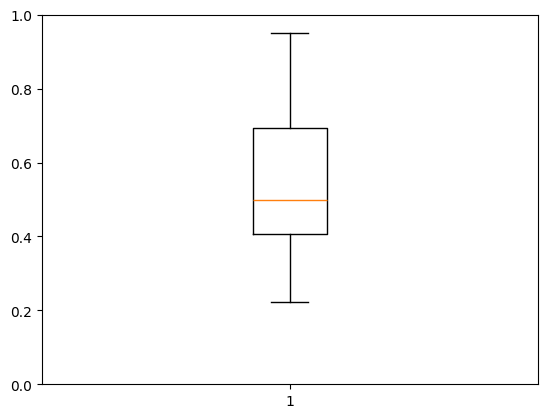

In [87]:
plt.boxplot(
    [res.compute_correlation(lambda arr_1, arr_2: float(pearsonr(arr_1.mean(axis=0), arr_2.mean(axis=0))[0])) for res in nmf_res]
)
plt.ylim(0, 1)

In [15]:
plt.boxplot(
    [res.compute_correlation(lambda arr_1, arr_2: float(pearsonr(arr_1.mean(axis=0), arr_2.mean(axis=0))[0])) for res in tangram_res],
)
plt.ylim(0, 1)

NameError: name 'tangram_res' is not defined

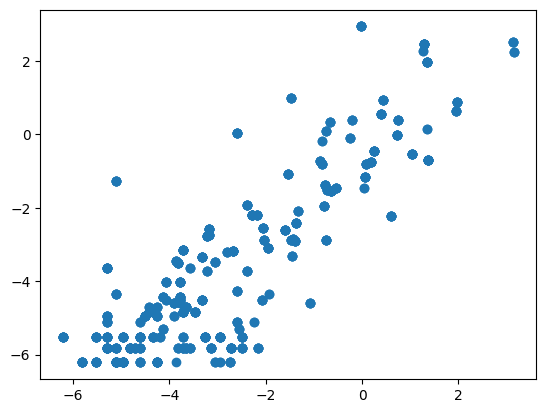

In [93]:
plt.scatter(
    np.log(np.hstack([res.original_counts.mean(axis=0) for res in tangram_res]) + 1e-3),
    np.log(np.hstack([res.predicted_counts.mean(axis=0) for res in tangram_res]) + 1e-3)
)

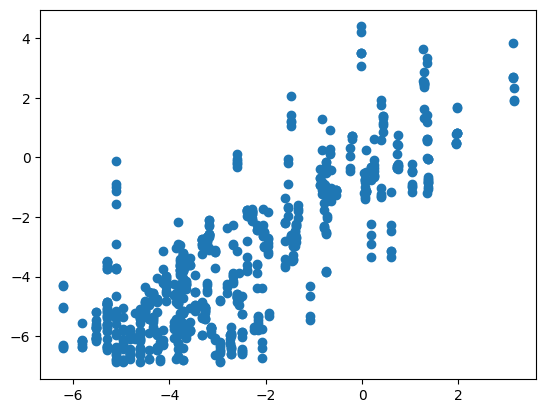

In [92]:
plt.scatter(
    np.log(np.hstack([res.original_counts.mean(axis=0) for res in nmf_res]) + 1e-3),
    np.log(np.hstack([res.predicted_counts.mean(axis=0) for res in nmf_res]) + 1e-3)
)

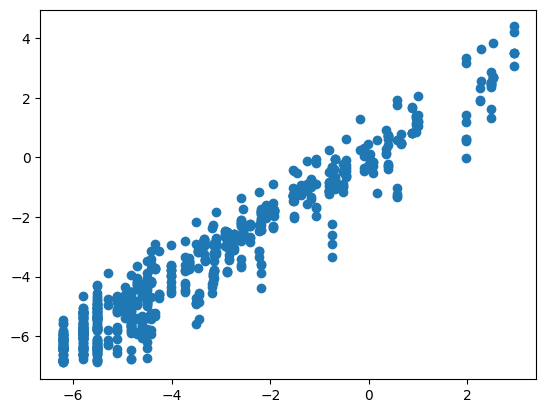

In [91]:
plt.scatter(
    np.log(np.hstack([res.predicted_counts.mean(axis=0) for res in tangram_res]) + 1e-3),
    np.log(np.hstack([res.predicted_counts.mean(axis=0) for res in nmf_res]) + 1e-3)
)

## Stem/TA

## Experimenting

In [329]:
def placeholder(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    base_genes: Sequence[str] | pd.Index,
    predicted_genes: Sequence[str] | pd.Index,
) -> tuple:

    (base_genes_query, predicted_genes_query), (base_genes_reference, predicted_genes_reference) = tuple(map(
        lambda adata: tuple(map(
            lambda genes: adata.var_names.get_indexer_for(genes), 
            (base_genes, predicted_genes))), (adata_query, adata_reference)))

    _, H_init, _ = non_negative_factorization(
        adata_reference[:, np.hstack([base_genes_reference, predicted_genes_reference])].X.toarray(), 
        n_components=n_components
    )
    W, _, _ = non_negative_factorization(
        adata_query[:, base_genes_query].X, 
        H=H_init[:, :len(base_genes)], 
        init="custom", 
        update_H=False,
        n_components=n_components
    )
    original_gene_counts = adata_query[:, predicted_genes].X.toarray()
    predicted_gene_counts = W @ H_init[:, -len(predicted_genes):]
    return original_gene_counts, predicted_gene_counts